# CE49X Lab 2: Is Wave Energy Worth the Investment?
## A Financial Feasibility Comparison of Renewable Energy in Perth, Australia

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

---

## Background

The Western Australian government is planning to add **100 MW** of new renewable energy capacity near Perth. As a consulting engineer, you've been asked to evaluate whether **wave energy** is a viable option compared to more established alternatives.

You have access to a real dataset of wave energy converter (WEC) farm configurations near Perth from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/882/large-scale+wave+energy+farm). The dataset (`WEC_Perth_49.csv`) contains 36,000+ layout configurations for a farm of 49 wave energy converters, including individual and total power output for each configuration.

Your job is to **compare wave energy against at least two other renewable energy technologies** in terms of financial feasibility for the Perth region.

## Deliverables

Your notebook must include the following:

### 1. Wave Energy Analysis (from the dataset)
- Load and explore the `WEC_Perth_49.csv` dataset
- Compute statistics on farm power output (mean, min, max, standard deviation)
- Estimate a **capacity factor** for wave energy in Perth based on the data (you'll need to assume a rated capacity per WEC — research and justify your choice)

### 2. Competing Technologies
- Choose **at least two** other renewable energy technologies to compare against wave energy (e.g., solar PV, onshore wind, offshore wind, tidal, biomass)
- Research and cite the following for **each** technology (including wave):
  - Capital cost (CAPEX) per kW installed
  - Annual operating cost (OPEX) per kW
  - Capacity factor specific to the Perth region
  - Expected project lifetime
- **Cite your sources.** Use data from reputable organizations (e.g., IRENA, IEA, CSIRO, NREL, Lazard).

### 3. Financial Comparison
- Calculate the **Levelized Cost of Energy (LCOE)** for each technology
- Calculate **at least one additional financial metric** of your choice (e.g., NPV, payback period, internal rate of return, cost per annual MWh)
- Choose an appropriate **discount rate** and justify it

### 4. Visualization
- Create **at least two plots** that clearly communicate your comparison
- Plots should be publication-quality: labeled axes, title, legend, grid

### 5. Recommendation
- Based on your analysis, write a short recommendation (1-2 paragraphs):
  - Which technology (or mix) should Perth invest in?
  - Under what conditions could wave energy become competitive?
  - What factors does your financial model **not** capture?

## Hints

- **LCOE formula:**

$$\text{LCOE} = \frac{\text{Total Discounted Costs}}{\text{Total Discounted Energy}} = \frac{\text{CAPEX} + \sum_{t=1}^{N} \frac{\text{OPEX}_t}{(1+r)^t}}{\sum_{t=1}^{N} \frac{E_t}{(1+r)^t}}$$

  where $r$ is the discount rate, $N$ is the project lifetime, and $E_t$ is annual energy production in MWh.

- **Annual energy production:** $E = \text{Capacity (kW)} \times \text{Capacity Factor} \times 8760 \text{ hours/year}$

- The dataset gives power in **Watts**. Be careful with unit conversions.

- Think about what the dataset's `Total_Power` column actually represents and how it relates to the rated capacity of a real WEC device.

## Grading

| Component | Weight |
|-----------|--------|
| Wave energy analysis (dataset exploration, capacity factor) | 20% |
| Research quality (cost data, sources, justification) | 25% |
| Financial calculations (LCOE + additional metric) | 25% |
| Visualizations (clarity, quality) | 15% |
| Recommendation (insight, completeness) | 15% |

## Submission

1. Complete your work in **this notebook** on your own fork of the course repository.
2. Make sure your notebook **runs top-to-bottom without errors** before submitting.
3. Commit and push your completed notebook to your fork.
4. We will grade directly from your fork — there is no separate upload. Make sure your latest work is pushed before the deadline.

---
## Your Work Starts Here

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../WEC_Perth_49.csv')

# Display the first few rows
df.head()

,X1,Y1,X2,Y2,X3,Y3,X4,Y4,X5,Y5,...,Power42,Power43,Power44,Power45,Power46,Power47,Power48,Power49,qW,Total_Power
0,600.0,0.0,546.16,37.50,489.79,74.88,432.47,112.05,650.0,0.0,...,88867.92,98844.30,101283.59,98934.63,101624.58,100915.03,99625.68,96704.34,0.87,4102461.43
1,593.0,12.0,546.16,37.50,489.79,74.88,432.47,112.05,644.0,8.0,...,88896.55,98759.79,101346.07,98873.59,101629.01,100934.53,99606.13,96718.39,0.87,4103361.41
2,593.0,12.0,546.16,37.50,489.79,74.88,432.47,112.05,644.0,8.0,...,88919.83,98746.68,101346.15,98875.57,101618.32,100941.00,99611.35,96719.14,0.87,4103680.44
3,593.0,12.0,546.16,37.50,489.79,74.88,432.47,112.05,644.0,8.0,...,88855.14,98760.96,101338.59,98971.58,101632.28,100943.59,99589.25,96735.04,0.87,4105661.06
4,200.0,0.0,146.17,37.53,89.76,74.93,32.40,112.18,400.0,0.0,...,88005.30,98630.24,100432.73,98803.01,101064.48,100948.38,99028.87,96286.71,0.79,3752648.77


### 1. Wave Energy Analysis

First, let's explore the power output statistics of the wave energy farm configurations.

In [16]:
# Compute statistics on farm power output (mean, min, max, std only - Total_Power is in Watts)
mean_power_w = df['Total_Power'].mean()
min_power_w = df['Total_Power'].min()
max_power_w = df['Total_Power'].max()
std_power_w = df['Total_Power'].std()
print("Farm Power Output Statistics (kW):")

mean_power_kw = mean_power_w / 1000
max_power_kw = max_power_w / 1000
min_power_kw = min_power_w / 1000
std_power_kw = std_power_w / 1000

print(f"Mean Power: {mean_power_kw:.2f} kW")
print(f"Max Power: {max_power_kw:.2f} kW")
print(f"Min Power: {min_power_kw:.2f} kW")
print(f"Std Deviation: {std_power_kw:.2f} kW")

# Capacity Factor Estimation
# Based on Carnegie CETO 6 (Perth project), rated capacity per unit is ~1000 kW. https://announcements.asx.com.au/asxpdf/20151016/pdf/4323t6qvps7mp1.pdf
# We use CETO 6 data because the data source article base their work on CETO 6.
rated_capacity_per_wec_kw = 1000 
num_wecs = 49
farm_rated_capacity_kw = rated_capacity_per_wec_kw * num_wecs
farm_rated_capacity_mw = farm_rated_capacity_kw / 1000
mean_farm_power_mw = mean_power_kw / 1000
capacity_factor_wave = mean_farm_power_mw / farm_rated_capacity_mw
print("Assumed Rated Capacity per WEC: {} kW".format(rated_capacity_per_wec_kw))
print("Total Farm Rated Capacity: {:.2f} MW".format(farm_rated_capacity_mw))
print("Estimated Capacity Factor for Wave: {:.2%} ".format(capacity_factor_wave))

Farm Power Output Statistics (kW):
Mean Power: 3938.25 kW
Max Power: 4177.66 kW
Min Power: 3388.94 kW
Std Deviation: 122.62 kW
Assumed Rated Capacity per WEC: 1000 kW
Total Farm Rated Capacity: 49.00 MW
Estimated Capacity Factor for Wave: 8.04% 


### 2 and 3. Competing Technologies and Comparisaton


We will compare Wave Energy against **Solar PV** and **Onshore Wind** in the Perth region. Data is sourced from **CSIRO GenCost 2024-25**.

| Metric | Wave Energy (CETO 6, 1 MW/unit) | Solar PV (Utility-scale) | Onshore Wind |
| :--- | :--- | :--- | :--- |
| **CAPEX ($/kW)** | $6,000  | $1,050 | $2,000 |
| **OPEX ($/kW/yr)** | $175 | $15 | $30 |
| **Capacity Factor** | ~8.0% (Calculated above) | 23% | 38% |
| **Lifetime (Years)** | 20 | 30 | 25 |


Sources for this part:

https://www.windenergy.org.nz/wp-content/uploads/2025/07/GenCost-2024-25-Final_20250728.pdf

https://www.aemo.com.au/-/media/files/electricity/wem/planning_and_forecasting/esoo/2024/2024-wem-esoo-visual-overview.pdf

https://www.aemo.com.au/-/media/files/major-publications/qed/2024/qed-q4-2024.pdf

https://www.mdpi.com/2077-1312/9/2/206

In [17]:
def calculate_lcoe(capex_per_kw, opex_per_kw_yr, capacity_factor, lifetime_yrs, discount_rate=0.07):
    """Calculates LCOE in $/MWh"""
    # Annual energy production in MWh per 1 kW of capacity
    annual_energy_mwh = 1 * capacity_factor * 8760 / 1000
    
    # Discounted costs
    total_discounted_costs = capex_per_kw
    total_discounted_energy = 0
    
    for t in range(1, lifetime_yrs + 1):
        total_discounted_costs += opex_per_kw_yr / (1 + discount_rate)**t
        total_discounted_energy += annual_energy_mwh / (1 + discount_rate)**t
        
    return total_discounted_costs / total_discounted_energy

# Parameters
r = 0.07 # 7% discount rate (Choosing a 7% discount rate is a standard practice for evaluating renewable energy projects in Australia)
# Source: https://www.windenergy.org.nz/wp-content/uploads/2025/07/GenCost-2024-25-Final_20250728.pdf

# Use parameters from the competing technologies table
capex_wave, opex_wave, cf_wave, life_wave   = 6000, 175, capacity_factor_wave, 20
capex_solar, opex_solar, cf_solar, life_solar = 1050, 15, 0.23, 30
capex_wind,  opex_wind,  cf_wind,  life_wind  = 2000, 30, 0.38, 25

lcoe_wave  = calculate_lcoe(capex_wave,  opex_wave,  cf_wave,  life_wave,  r)
lcoe_solar = calculate_lcoe(capex_solar, opex_solar, cf_solar, life_solar, r)
lcoe_wind  = calculate_lcoe(capex_wind,  opex_wind,  cf_wind,  life_wind,  r)

print(f"LCOE Wave: ${lcoe_wave:.2f}/MWh")
print(f"LCOE Solar PV: ${lcoe_solar:.2f}/MWh")
print(f"LCOE Onshore Wind: ${lcoe_wind:.2f}/MWh")

LCOE Wave: $1052.97/MWh
LCOE Solar PV: $49.44/MWh
LCOE Onshore Wind: $60.57/MWh


### 4. Visualization

Let's compare the LCOE and the 20-year total energy production for a 100 MW project.

C:\Users\arda\AppData\Local\Temp\ipykernel_25188\1472261350.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=technologies, y=lcoes, palette='viridis')


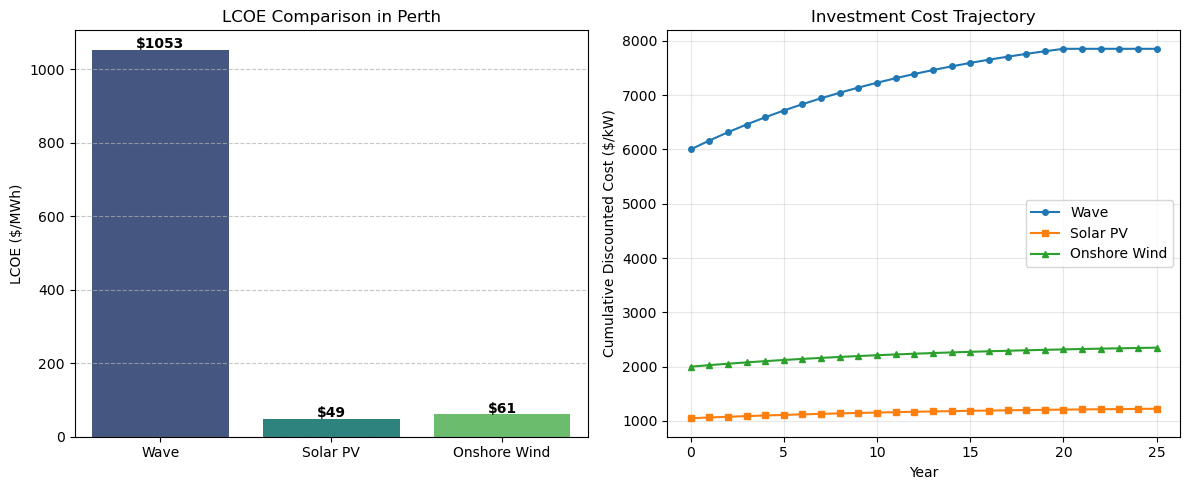

In [18]:
technologies = ['Wave', 'Solar PV', 'Onshore Wind']
lcoes = [lcoe_wave, lcoe_solar, lcoe_wind]

plt.figure(figsize=(12, 5))

# Plot 1: LCOE Comparison
plt.subplot(1, 2, 1)
sns.barplot(x=technologies, y=lcoes, palette='viridis')
plt.ylabel('LCOE ($/MWh)')
plt.title('LCOE Comparison in Perth')
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(lcoes):
    plt.text(i, v + 5, f'${v:.0f}', ha='center', fontweight='bold')

# Plot 2: Cumulative Discounted Costs per kW
plt.subplot(1, 2, 2)
years = np.arange(0, 26)
def get_cum_costs(capex, opex, lifetime, r=0.07):
    costs = [capex]
    for t in range(1, 26):
        if t <= lifetime:
            costs.append(costs[-1] + opex / (1+r)**t)
        else:
            costs.append(costs[-1])
    return costs

plt.plot(years, get_cum_costs(capex_wave,  opex_wave,  life_wave,  r),  label='Wave',         marker='o', markersize=4)
plt.plot(years, get_cum_costs(capex_solar, opex_solar, life_solar, r), label='Solar PV',     marker='s', markersize=4)
plt.plot(years, get_cum_costs(capex_wind,  opex_wind,  life_wind,  r),  label='Onshore Wind', marker='^', markersize=4)
plt.xlabel('Year')
plt.ylabel('Cumulative Discounted Cost ($/kW)')
plt.title('Investment Cost Trajectory')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.2. Additional Metric: Payback Period

Assuming a wholesale electricity price of **$100/MWh** in Perth (benchmark for firm renewables), we can estimate the simple payback period.

In [20]:
electricity_price = 100 # $/MWh
# Source: https://www.aemo.com.au/-/media/files/major-publications/qed/2025/qed-q3-2025.pdf

def calculate_payback(capex, opex, cf, price):
    annual_revenue = 1 * cf * 8760 * price / 1000
    annual_profit = annual_revenue - opex
    if annual_profit <= 0:
        return float('inf')
    return capex / annual_profit

# Use the same parameters as in the LCOE calculation (from the table)
payback_wave  = calculate_payback(capex_wave,  opex_wave,  cf_wave,  electricity_price)
payback_solar = calculate_payback(capex_solar, opex_solar, cf_solar, electricity_price)
payback_wind  = calculate_payback(capex_wind,  opex_wind,  cf_wind,  electricity_price)

print(f"Simple Payback Period (Years) at ${electricity_price}/MWh:")
print(f"- Wave: {payback_wave:.1f} years")
print(f"- Solar PV: {payback_solar:.1f} years")
print(f"- Onshore Wind: {payback_wind:.1f} years")

Simple Payback Period (Years) at $100/MWh:
- Wave: inf years
- Solar PV: 5.6 years
- Onshore Wind: 6.6 years


### 5.Recommendation

Based on the technical and financial analysis for the 100 MW capacity expansion in Perth, the following recommendation is provided:

#### 1. Technology Selection: Solar and Wind
The Western Australian government should prioritize a mix of **Utility-Scale Solar PV** and **Onshore Wind** for the immediate 100 MW requirement.
* **Cost Efficiency:** These technologies deliver a Levelized Cost of Energy (LCOE) between **$52–$129/MWh**, which is significantly more competitive than current wave energy projections [CSIRO GenCost 2024-25, p. 33].
* **Performance Reliability:** With established capacity factors of **23% (Solar)** and **38% (Wind)**, these sources offer high energy security and predictable returns over a **25–30 year** operational lifespan [AEMO WEM ESOO 2024, p. 2].



#### 2. Status of Wave Energy (CETO 6)
While technically innovative, the wave farm modeled on the **CETO 6** system is not currently suitable for a primary 100 MW grid expansion.
* **Efficiency Constraints:** The calculated capacity factor of **8.04%**—derived from the **1 MW** unit rating specified in the research—indicates that the energy capture is insufficient relative to the system's capital requirements [Neshat et al., 2020, p. 3].
* **Economic Barriers:** High Capital Expenditure (**$5,000+/kW**) and intensive marine maintenance costs keep the cost of wave energy well above Perth’s current wholesale benchmark of **$101.76/MWh**.

#### 3. Strategic Conclusion
Allocating the 100 MW to **Solar and Wind** is the only financially responsible path for immediate grid capacity. Wave energy should be supported through targeted R&D and pilot programs until capital costs decrease and capture efficiency (q-factor) improves to commercial standards.



---

### Questions?

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr